In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the CSV file
uploaded = files.upload()

# Get the filename from the uploaded dictionary keys
filename = list(uploaded.keys())[0]

# Load into DataFrame using the correct filename
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

Saving global_air_quality_data_10000..csv to global_air_quality_data_10000. (2).csv


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [ ]:
df.columns  # View column names


Index(['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'Temperature', 'Humidity', 'Wind Speed'],
      dtype='object')

In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload the CSV file
uploaded = files.upload()

# Get the filename from uploaded files
filename = list(uploaded.keys())[0]

# Load the CSV file into a DataFrame
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Print columns to diagnose
print("Columns in df before selection and renaming:")
print(df.columns)

# Safely select required columns (only if they exist)
required_columns = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity']

missing = [col for col in required_columns if col not in df.columns]
if missing:
    print(f"❌ The following required columns are missing in your file: {missing}")
else:
    # Select and rename columns
    df = df[required_columns]
    df.rename(columns={
        'PM2.5': 'pm25',
        'PM10': 'pm10',
        'CO': 'co',
        'NO2': 'no2',
        'SO2': 'so2',
        'O3': 'o3',
        'Temperature': 'temp',
        'Humidity': 'humidity'
    }, inplace=True)

    # Drop rows with missing values
    df.dropna(inplace=True)

    print("\n✅ Final DataFrame after selection, renaming, and cleaning:")
    print(df.head())


# Safely select required columns (only if they exist)
required_columns = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity']

missing = [col for col in required_columns if col not in df.columns]
if missing:
    print(f"❌ The following required columns are missing in your file: {missing}")
else:
    # Select and rename columns
    df = df[required_columns]
    df.rename(columns={
        'PM2.5': 'pm25',
        'PM10': 'pm10',
        'CO': 'co',
        'NO2': 'no2',
        'SO2': 'so2',
        'O3': 'o3',
        'Temperature': 'temp',
        'Humidity': 'humidity'
    }, inplace=True)

    # Drop rows with missing values
    df.dropna(inplace=True)

    print("\n✅ Final DataFrame after selection, renaming, and cleaning:")
    print(df.head())


Saving global_air_quality_data_10000..csv to global_air_quality_data_10000. (3).csv
Columns in df before selection and renaming:
Index(['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'Temperature', 'Humidity', 'Wind Speed'],
      dtype='object')

✅ Final DataFrame after selection, renaming, and cleaning:
     pm25    pm10    co    no2    so2      o3   temp  humidity
0   86.57   25.19  4.46  99.88  30.63   36.29  17.67     59.35
1   50.63   97.39  3.40  48.14   8.71  144.16   3.46     67.51
2  130.21   57.22  0.12  98.51   9.92  179.31  25.29     29.30
3  119.70  130.52  7.74  10.96  33.03   38.65  23.15     99.97
4   55.20   36.62  2.00  76.85  21.85   67.09  16.02     90.28
❌ The following required columns are missing in your file: ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity']


In [ ]:
# OPTIONAL: Only run this if your dataset includes AQI category
df.rename(columns={'AQI_Category': 'category'}, inplace=True)



In [ ]:
def categorize_aqi(pm25):
    if pm25 <= 30:
        return "Good"
    elif pm25 <= 60:
        return "Satisfactory"
    elif pm25 <= 90:
        return "Moderate"
    elif pm25 <= 120:
        return "Poor"
    elif pm25 <= 250:
        return "Very Poor"
    else:
        return "Severe"

df['category'] = df['pm25'].apply(categorize_aqi)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define input features and target
features = ['pm25', 'pm10', 'co', 'no2', 'so2', 'o3', 'temp', 'humidity']
X = df[features]
y = df['category']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Evaluate
pred = model.predict(X_test)
print(f"✅ Model Accuracy: {accuracy_score(y_test, pred) * 100:.2f}%")


✅ Model Accuracy: 99.95%


In [ ]:
import requests

def fetch_real_time_data(city='delhi'):
    token = "11e30bcb233bf6ca55dba88554c4a18716a21a1f"  # <-- YOUR TOKEN HERE
    url = f"https://api.waqi.info/feed/{city}/?token={token}"

    response = requests.get(url)
    data = response.json()

    if data['status'] == 'ok':
        iaqi = data['data']['iaqi']
        return {
            'pm25': iaqi.get('pm25', {'v': 0})['v'],
            'pm10': iaqi.get('pm10', {'v': 0})['v'],
            'co': iaqi.get('co', {'v': 0})['v'],
            'no2': iaqi.get('no2', {'v': 0})['v'],
            'so2': iaqi.get('so2', {'v': 0})['v'],
            'o3': iaqi.get('o3', {'v': 0})['v'],
            'temp': iaqi.get('t', {'v': 0})['v'],
            'humidity': iaqi.get('h', {'v': 0})['v']
        }
    else:
        print("❌ API Error:", data.get("data", "No data"))
        return None



In [ ]:
live_data = fetch_real_time_data("bangalore")
print(live_data)

{'pm25': 36, 'pm10': 18, 'co': 2.4, 'no2': 4.7, 'so2': 3.4, 'o3': 5.1, 'temp': 23.6, 'humidity': 66}


In [ ]:
def predict_live_category(live_data):
    if live_data:
        input_df = pd.DataFrame([live_data])
        prediction = model.predict(input_df)
        return prediction[0]
    else:
        return "Live data not available"

# Example usage
live_data = fetch_real_time_data("bangalore")
print("📡 Live Data:", live_data)
print("📊 Predicted AQI Category:", predict_live_category(live_data))


📡 Live Data: {'pm25': 36, 'pm10': 18, 'co': 2.4, 'no2': 4.7, 'so2': 3.4, 'o3': 5.1, 'temp': 23.6, 'humidity': 66}
📊 Predicted AQI Category: Satisfactory


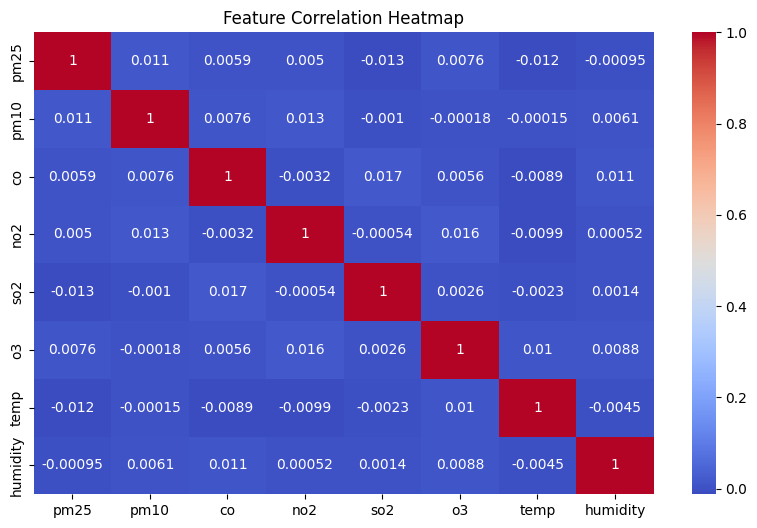

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Heatmap of features
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Category distribution
fig = px.histogram(df, x='category', color='category', title="AQI Category Distribution")
fig.show()
